In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import jieba.analyse
# Save the image
import time

In [53]:
path='.\\Window\\'
filename='175741env_prb_406507env_prb_241564CleanedEnvPrbAll.csv6499临时存储sentiment_level.csvsentiment_level.csv'

In [54]:
df=pd.read_csv(path+filename,encoding='utf-8')

In [55]:
df.head()

,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Name,Date,Content,Env_prlbm,Sent_lvl
0,0,0,0,3,3,3,--东曦--,2023年03月28日 00:02 来自 HUAWEI Mate 40E,发工资 没有周末没有假期 没有同龄人请假回家几天想想 回去那个宿舍和办公室楼上楼下还有那个没...,1,-1
1,1,1,1,4,4,4,Vanessa-Ives,2023年03月27日 23:34 来自 iPhone客户端,办公室搬到 楼后改成自动感应灯，只 有动静灯 会一直亮 ，窗户反射出 室内， 拍 出维港...,1,1
2,2,2,2,6,7,7,椰椰少女啵,2023年03月27日 20:28 来自 iPhone客户端,人生抓马事件 第一次找导师讨论论文 被锁 办公室 导师隔 门上 小窗户喊来两个老师，一起...,1,1
3,3,3,3,11,12,12,王优秀·-,2023年03月27日 14:45 来自 iPhone客户端,单位 施工 办公室窗户外边有工人👷 现 还**开空调嘛👷 看，公家 电， 花自己一分钱👷...,1,-1
4,4,4,4,13,15,15,狂野迪仔,2023年03月27日 12:51 来自 Android,办公室可真冷 这个窗户 风一直往 这吹,1,-1


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7086 entries, 0 to 7085
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.5  7086 non-null   int64 
 1   Unnamed: 0.4  7086 non-null   int64 
 2   Unnamed: 0.3  7086 non-null   int64 
 3   Unnamed: 0.2  7086 non-null   int64 
 4   Unnamed: 0.1  7086 non-null   int64 
 5   Unnamed: 0    7086 non-null   int64 
 6   Name          7086 non-null   object
 7   Date          7086 non-null   object
 8   Content       7086 non-null   object
 9   Env_prlbm     7086 non-null   int64 
 10  Sent_lvl      7086 non-null   object
dtypes: int64(7), object(4)
memory usage: 609.1+ KB


In [57]:
df['Sent_lvl']=pd.to_numeric(df['Sent_lvl'], errors='coerce')

In [66]:
df_ng=df[df['Sent_lvl']>0]

In [67]:
df_ng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 902 entries, 1 to 7082
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.5  902 non-null    int64  
 1   Unnamed: 0.4  902 non-null    int64  
 2   Unnamed: 0.3  902 non-null    int64  
 3   Unnamed: 0.2  902 non-null    int64  
 4   Unnamed: 0.1  902 non-null    int64  
 5   Unnamed: 0    902 non-null    int64  
 6   Name          902 non-null    object 
 7   Date          902 non-null    object 
 8   Content       902 non-null    object 
 9   Env_prlbm     902 non-null    int64  
 10  Sent_lvl      902 non-null    float64
dtypes: float64(1), int64(7), object(3)
memory usage: 84.6+ KB


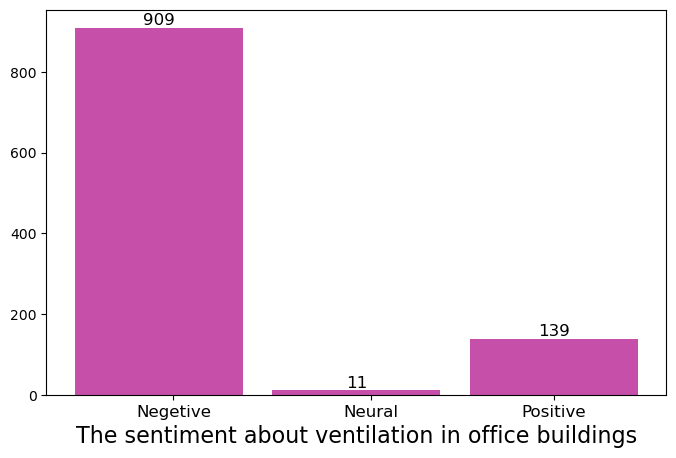

In [25]:
import random
# 生成随机颜色（RGB格式）
random_color = (random.random(), random.random(), random.random())
ax=df['Sent_lvl'].hist(bins=3, rwidth=0.85, figsize=(8, 5), alpha=0.7,color=random_color)
# 1. 去掉 grid
ax.grid(False)
# 2. 去掉 x 轴标签
ax.set_xlabel('')
# 2. 增加数据标签（遍历每个 patch 添加高度文本）
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12
        )

# 3. 计算每个 patch 的位置，设置 xtick 在 patch 下方中央
patches = ax.patches
bin_edges = [p.get_x() for p in patches] + [patches[-1].get_x() + patches[-1].get_width()]
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(patches))]
ax.set_xticks(bin_centers)
ax.set_xticklabels(['Negetive','Neural','Positive'],ha='center', fontsize=12)
#ax.legend('AC sentiment',loc='center',bbox_to_anchor=(0.5, 0., 0.5, 0.5),borderaxespad=0)
ax.set_xlabel('The sentiment about ventilation in office buildings',fontsize=16)
plt.savefig(path+str(time.time())[-6:]+'_sentiment.png')
#plt.tight_layout()
plt.show()

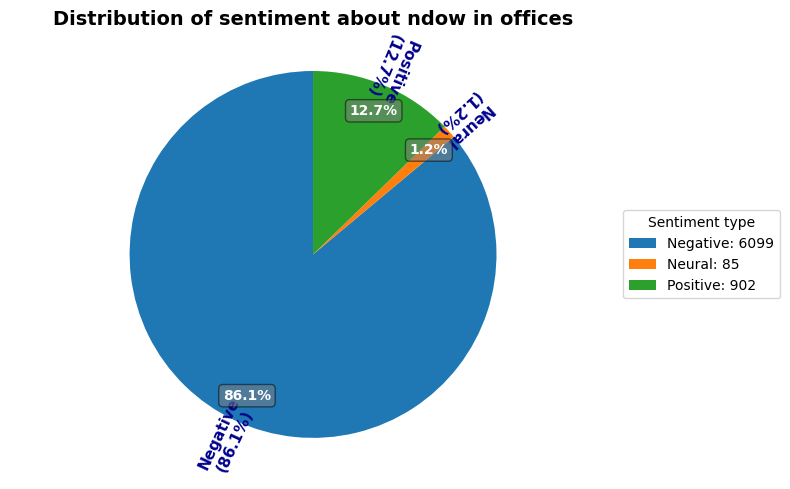

In [68]:
# 示例数据
data = pd.Series([6099, 85, 902], 
                 index=['Negative', 'Neural', 'Positive'])

# 计算百分比
percentages = (data / data.sum()) * 100

# 创建图形
fig, ax = plt.subplots(figsize=(8, 5))

# 绘制饼图
wedges, texts, autotexts = ax.pie(data, 
                                    autopct='%1.1f%%',
                                    textprops={'fontsize': 12},
                                    pctdistance=0.85,  # 占比标签距离圆心的距离
                                    labeldistance=1.1,  # 类别标签距离圆心的距离
                                    startangle=90,
                                    )  # 突出第一块explode=[0.05, 0, 0]

# 手动设置类别标签（texts）的属性和位置
for i, text in enumerate(texts):
    # 设置标签文字
    text.set_text(f"{data.index[i]}\n({percentages.iloc[i]:.1f}%)")  # 在标签中同时显示类别和占比
    text.set_fontsize(11)
    text.set_fontweight('bold')
    text.set_color('darkblue')
    
    # 获取当前标签的角度并设置旋转
    angle = (wedges[i].theta2 + wedges[i].theta1) / 2
    if angle > 180:
        angle -= 180
    text.set_rotation(angle)
    text.set_horizontalalignment('center')

# 手动设置占比标签（autotexts）的样式
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_bbox(dict(boxstyle='round', facecolor='gray', alpha=0.5))

# 添加标题
plt.title(f'Distribution of sentiment about {path[-5:-1]} in offices', fontsize=14, fontweight='bold', pad=20)

# 确保饼图是圆形
ax.axis('equal')

# 添加图例
ax.legend(wedges, [f"{idx}: {val}" for idx, val in data.items()],
          title="Sentiment type",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.savefig(path+str(time.time())[-6:]+'bar_sentiment.png')
plt.show()

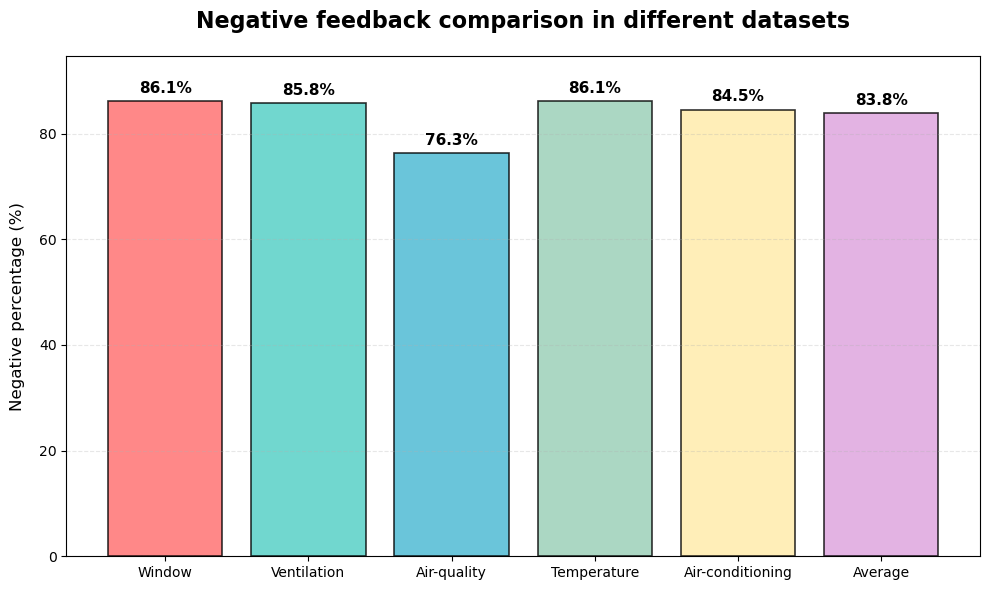

In [70]:
# 示例数据（字典格式）
data_dict = {
    'Window': 86.1,
    'Ventilation': 85.8,
    'Air-quality': 76.3,
    'Temperature': 86.1,
    'Air-conditioning':84.5,
    'Average':83.8
}
colors_manual = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
# 从字典中提取键和值
categories = list(data_dict.keys())  # 类别名称（x轴）
values = list(data_dict.values())      # 数值（y轴）

# 创建图形和轴对象
plt.figure(figsize=(10, 6))

# 绘制柱状图
bars = plt.bar(categories, values, 
               color=colors_manual,     # 柱子颜色
               edgecolor='black',    # 边框颜色
               linewidth=1.2,        # 边框宽度
               alpha=0.8)            # 透明度

# 添加数值标签（在每个柱子上方显示数值）
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height}%',  # 显示整数
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# 设置标题和轴标签
plt.title('Negative feedback comparison in different datasets', fontsize=16, fontweight='bold', pad=20)
#plt.xlabel('In different datasets', fontsize=12, labelpad=10)
plt.ylabel('Negative percentage (%)', fontsize=12, labelpad=10)

# 设置y轴范围（留出空间显示标签）
plt.ylim(0, max(values) * 1.1)

# 添加网格线（仅在y轴）
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 旋转x轴标签（如果类别过多可启用）
# plt.xticks(rotation=45, ha='right')

# 调整布局防止标签被裁剪
plt.tight_layout()
# 可选：保存图片
plt.savefig(str(time.time())[-6:]+'negative_feedback_barchart.png', dpi=300, bbox_inches='tight')
# 显示图表
plt.show()



In [69]:
my_dict = {'Window': 86.1,
    'Ventilation': 85.8,
    'Air-quality': 76.3,
    'Temperature': 86.1,
    'Air-conditioning':84.5}

# 方法1：使用 values() 和 sum()/len()
average = sum(my_dict.values()) / len(my_dict)
print(average)  # 输出: 25.0

83.75999999999999
